# Snake: Learning to Live — Data Analysis

In [2]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans

BG = '#1e1e2e'; TC = '#cdd6f4'; GC = '#313244'
ACCENT = {'Random':'#f38ba8','BFS':'#89b4fa','A*':'#a6e3a1','Hamiltonian':'#f9e2af','DQN':'#cba6f7'}

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': BG,
    'text.color': TC, 'axes.labelcolor': TC,
    'xtick.color': TC, 'ytick.color': TC,
    'axes.spines.top': False, 'axes.spines.right': False
})
print('All imports OK')

All imports OK


## 1. Data Analysis

In [3]:
agent_df    = pd.read_csv('data_agent.csv')
marathon_df = pd.read_csv('data_marathon.csv')
print('Solo DQN shape    :', agent_df.shape)
print('Marathon shape    :', marathon_df.shape)
print('Marathon agents   :', marathon_df['agent'].unique())
agent_df.head()

Solo DQN shape    : (575, 4)
Marathon shape    : (22311, 5)
Marathon agents   : <StringArray>
['DQN', 'Random', 'A*', 'BFS', 'Hamiltonian']
Length: 5, dtype: str


,game_num,score,record,mean_score
0,1,0,0,0.000
1,2,1,1,0.500
2,3,0,1,0.333
3,4,0,1,0.250
4,5,0,1,0.200


In [4]:
agent_df.describe().round(2)

,game_num,score,record,mean_score
count,575.00,575.00,575.00,575.00
mean,288.00,27.55,64.05,19.34
std,166.13,16.78,25.57,9.70
min,1.00,0.00,0.00,0.00
25%,144.50,17.00,66.00,14.01
50%,288.00,28.00,78.00,24.64
75%,431.50,39.00,78.00,26.56
max,575.00,78.00,78.00,27.56


In [5]:
# Per-agent statistics from marathon
summary = marathon_df.groupby('agent')['score'].agg(
    games='count', mean='mean', std='std', median='median', max='max'
).round(2).sort_values('mean', ascending=False)
print(summary)

             games    mean    std  median  max
agent                                         
Hamiltonian     38  297.00   0.00   297.0  297
A*            1201   50.83  13.30    51.0   92
BFS           1193   50.77  14.08    51.0   94
DQN           2624   23.17  10.57    23.0   63
Random       17255    0.12   0.34     0.0    3


/tmp/ipykernel_107673/726431544.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_by_agent, patch_artist=True,


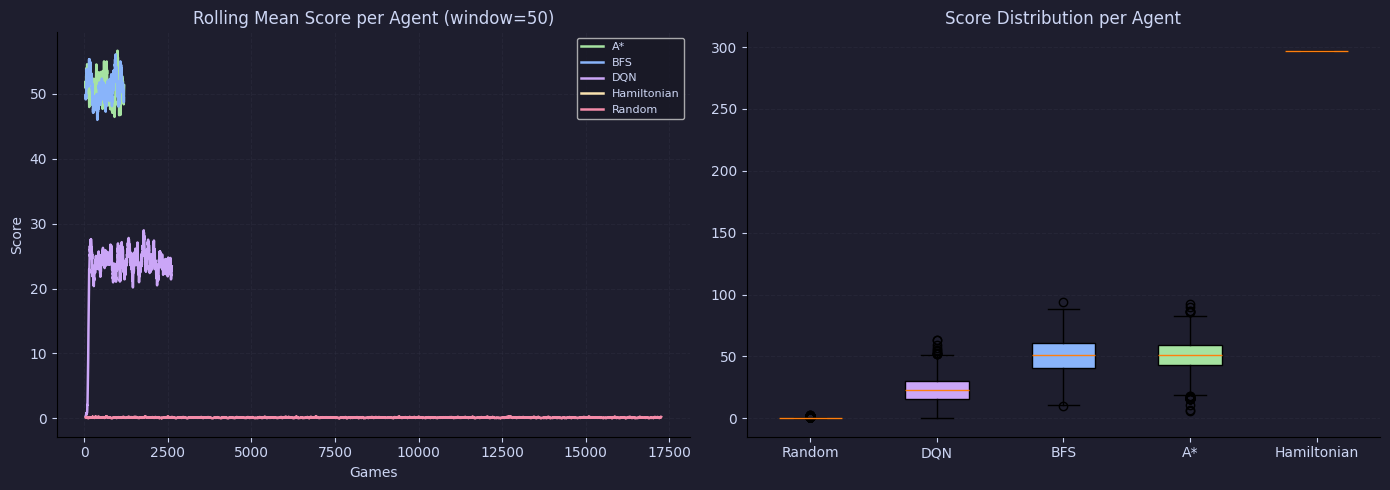

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for agent, grp in marathon_df.groupby('agent'):
    rm = grp['score'].rolling(50).mean()
    ax.plot(rm.values, label=agent, color=ACCENT.get(agent, '#cdd6f4'), linewidth=1.8)
ax.set_title('Rolling Mean Score per Agent (window=50)', color=TC)
ax.set_xlabel('Games'); ax.set_ylabel('Score')
ax.legend(facecolor='#181825', labelcolor=TC, fontsize=8)
ax.grid(color=GC, linestyle='--', alpha=0.4)

ax2 = axes[1]
data_by_agent = [marathon_df[marathon_df['agent']==a]['score'].values
                 for a in ['Random','DQN','BFS','A*','Hamiltonian']]
bp = ax2.boxplot(data_by_agent, patch_artist=True,
                 labels=['Random','DQN','BFS','A*','Hamiltonian'])
for patch, color in zip(bp['boxes'], ['#f38ba8','#cba6f7','#89b4fa','#a6e3a1','#f9e2af']):
    patch.set_facecolor(color)
ax2.set_title('Score Distribution per Agent', color=TC)
ax2.grid(color=GC, linestyle='--', alpha=0.4, axis='y')

plt.tight_layout()
plt.savefig('analysis_fig1_pandas.png', dpi=120, bbox_inches='tight', facecolor=BG)
plt.show()

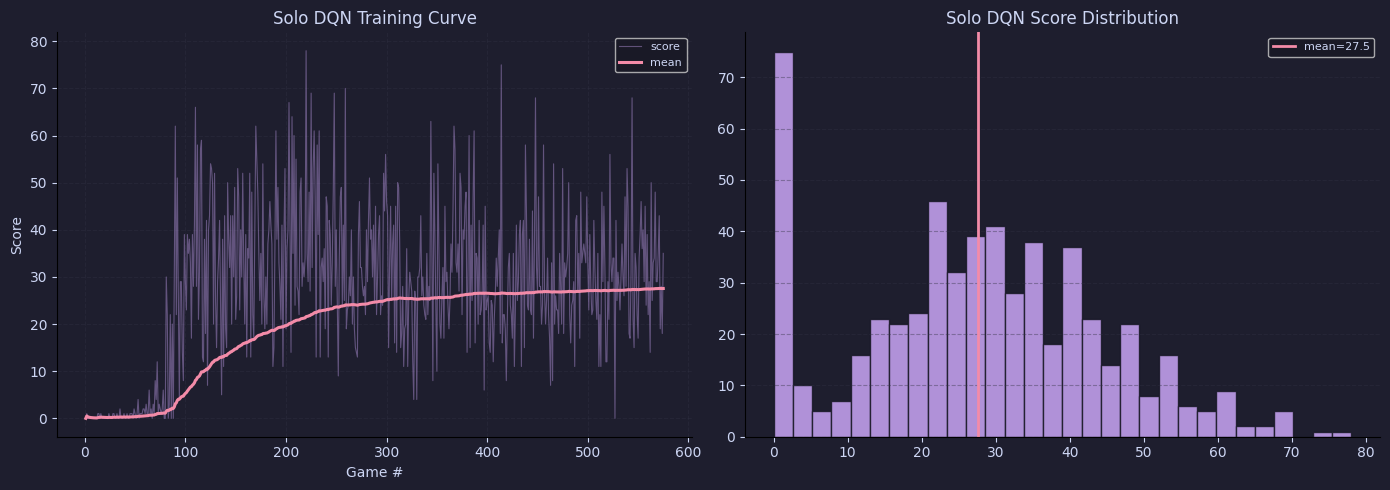

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(agent_df['game_num'], agent_df['score'], color='#cba6f7', alpha=0.4, linewidth=0.8, label='score')
ax.plot(agent_df['game_num'], agent_df['mean_score'], color='#f38ba8', linewidth=2.2, label='mean')
ax.set_title('Solo DQN Training Curve', color=TC)
ax.set_xlabel('Game #'); ax.set_ylabel('Score')
ax.legend(facecolor='#181825', labelcolor=TC, fontsize=8)
ax.grid(color=GC, linestyle='--', alpha=0.4)

ax2 = axes[1]
ax2.hist(agent_df['score'], bins=30, color='#cba6f7', edgecolor='#181825', alpha=0.85)
ax2.axvline(agent_df['score'].mean(), color='#f38ba8', linewidth=2,
            label=f"mean={agent_df['score'].mean():.1f}")
ax2.set_title('Solo DQN Score Distribution', color=TC)
ax2.legend(facecolor='#181825', labelcolor=TC, fontsize=8)
ax2.grid(color=GC, linestyle='--', alpha=0.4, axis='y')

plt.tight_layout()
plt.savefig('analysis_fig2_solo_dqn.png', dpi=120, bbox_inches='tight', facecolor=BG)
plt.show()

## 2. Data Preparation — Feature Engineering & Train/Test Split

In [8]:
df = agent_df.copy()
df['rolling_mean_10'] = df['score'].rolling(10, min_periods=1).mean()
df['score_delta']     = df['score'].diff().fillna(0)
df['phase']           = pd.cut(df['game_num'], bins=[0,80,200,575],
                                labels=['Exploration','Learning','Plateau'])
df['above_mean']      = (df['score'] > df['mean_score']).astype(int)

print('Features added:')
print(df[['game_num','score','rolling_mean_10','score_delta','phase','above_mean']].head(10).to_string())
print(f"\nClass balance: {df['above_mean'].value_counts().to_dict()}")

Features added:
   game_num  score  rolling_mean_10  score_delta        phase  above_mean
0         1      0         0.000000          0.0  Exploration           0
1         2      1         0.500000          1.0  Exploration           1
2         3      0         0.333333         -1.0  Exploration           0
3         4      0         0.250000          0.0  Exploration           0
4         5      0         0.200000          0.0  Exploration           0
5         6      0         0.166667          0.0  Exploration           0
6         7      0         0.142857          0.0  Exploration           0
7         8      0         0.125000          0.0  Exploration           0
8         9      0         0.111111          0.0  Exploration           0
9        10      0         0.100000          0.0  Exploration           0

Class balance: {1: 387, 0: 188}


In [9]:
FEATURES = ['game_num', 'rolling_mean_10', 'score_delta', 'record']
TARGET   = 'above_mean'

X = df[FEATURES].values
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                     random_state=42, stratify=y)
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples')
print(f'Features: {FEATURES}')

Train: 460 samples  |  Test: 115 samples
Features: ['game_num', 'rolling_mean_10', 'score_delta', 'record']


## 3. Supervised Learning — Regression

Slope (improvement per game): 0.0342
R²  : 0.1113
RMSE: 14.43


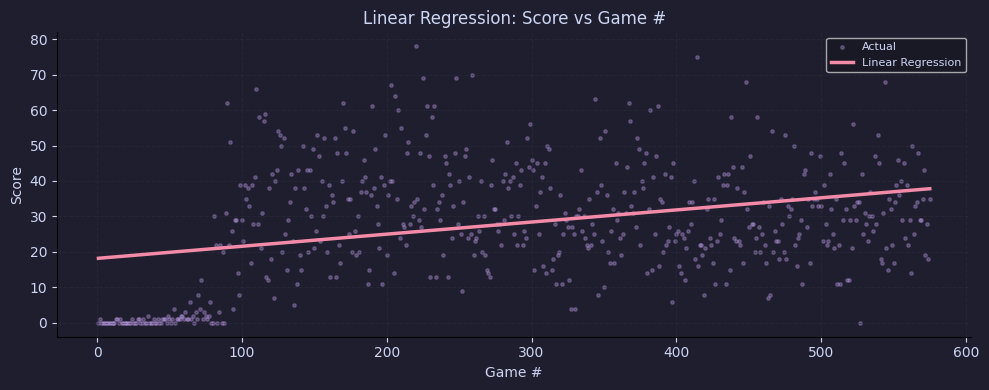

In [10]:
X_reg = df[['game_num']].values
y_reg = df['score'].values
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

lr = LinearRegression().fit(Xr_tr, yr_tr)
yr_pred = lr.predict(Xr_te)

print(f'Slope (improvement per game): {lr.coef_[0]:.4f}')
print(f'R²  : {r2_score(yr_te, yr_pred):.4f}')
rmse = np.sqrt(mean_squared_error(yr_te, yr_pred))
print(f'RMSE: {rmse:.2f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(df['game_num'], df['score'], color='#cba6f7', alpha=0.3, s=6, label='Actual')
x_line = np.linspace(1, 575, 200).reshape(-1, 1)
ax.plot(x_line, lr.predict(x_line), color='#f38ba8', linewidth=2.5, label='Linear Regression')
ax.set_title('Linear Regression: Score vs Game #', color=TC)
ax.set_xlabel('Game #'); ax.set_ylabel('Score')
ax.legend(facecolor='#181825', labelcolor=TC, fontsize=8)
ax.grid(color=GC, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('analysis_fig4_linreg.png', dpi=120, bbox_inches='tight', facecolor=BG)
plt.show()

## 4. Supervised Learning — Classification (Decision Tree, Logistic Reg, SVM, Random Forest, ANN)

In [11]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=5, random_state=42),
    'SVM'                : SVC(kernel='rbf', random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'ANN (MLP)'          : MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500, random_state=42),
}

results = {}
for name, model in models.items():
    Xs_tr = X_train if name == 'Decision Tree' else X_train_sc
    Xs_te = X_test  if name == 'Decision Tree' else X_test_sc
    model.fit(Xs_tr, y_train)
    acc = accuracy_score(y_test, model.predict(Xs_te))
    results[name] = acc
    print(f'{name:<22}  accuracy: {acc:.4f}')

print('\nDetailed report — Random Forest:')
print(classification_report(y_test, models['Random Forest'].predict(X_test_sc),
                             target_names=['Below Avg','Above Avg']))

Logistic Regression     accuracy: 0.7739
Decision Tree           accuracy: 0.7652
SVM                     accuracy: 0.8174
Random Forest           accuracy: 0.8348
ANN (MLP)               accuracy: 0.8087

Detailed report — Random Forest:
              precision    recall  f1-score   support

   Below Avg       0.77      0.71      0.74        38
   Above Avg       0.86      0.90      0.88        77

    accuracy                           0.83       115
   macro avg       0.82      0.80      0.81       115
weighted avg       0.83      0.83      0.83       115



/home/aarnya-jain/.local/share/mise/installs/python/3.13.5/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


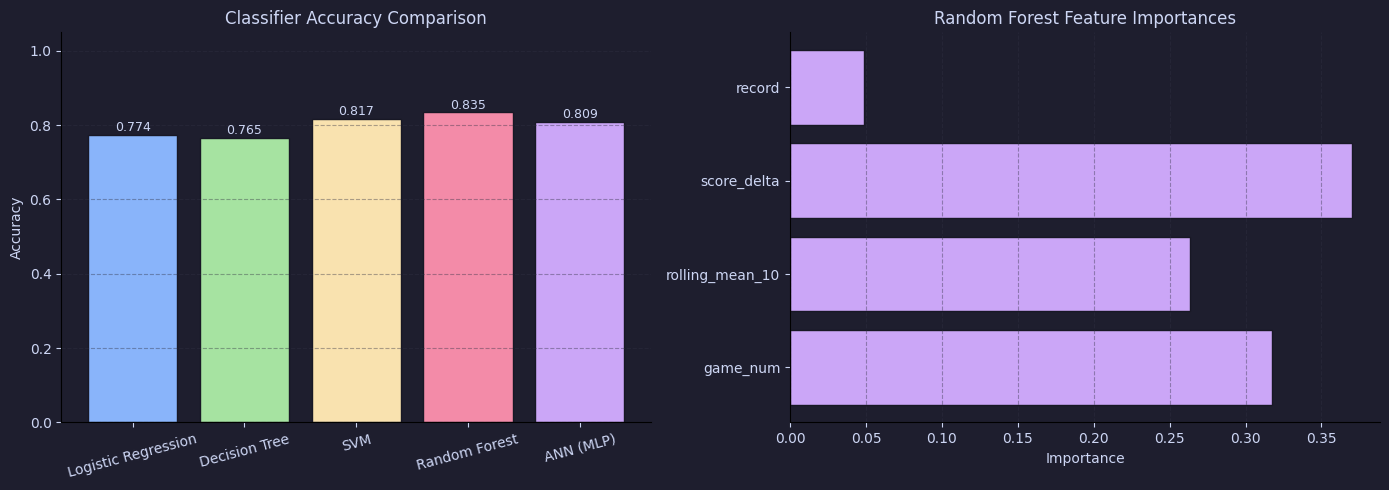

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
names = list(results.keys())
accs  = list(results.values())
cols  = ['#89b4fa','#a6e3a1','#f9e2af','#f38ba8','#cba6f7']
bars  = ax.bar(names, accs, color=cols, edgecolor='#181825')
ax.set_ylim(0, 1.05)
ax.set_title('Classifier Accuracy Comparison', color=TC)
ax.set_ylabel('Accuracy')
ax.tick_params(axis='x', rotation=15)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{acc:.3f}', ha='center', color=TC, fontsize=9)
ax.grid(color=GC, linestyle='--', alpha=0.4, axis='y')

ax2 = axes[1]
imp = models['Random Forest'].feature_importances_
ax2.barh(FEATURES, imp, color='#cba6f7', edgecolor='#181825')
ax2.set_title('Random Forest Feature Importances', color=TC)
ax2.set_xlabel('Importance')
ax2.grid(color=GC, linestyle='--', alpha=0.4, axis='x')

plt.tight_layout()
plt.savefig('analysis_fig5_classifiers.png', dpi=120, bbox_inches='tight', facecolor=BG)
plt.show()

## 5. Unsupervised Learning — K-Means Clustering

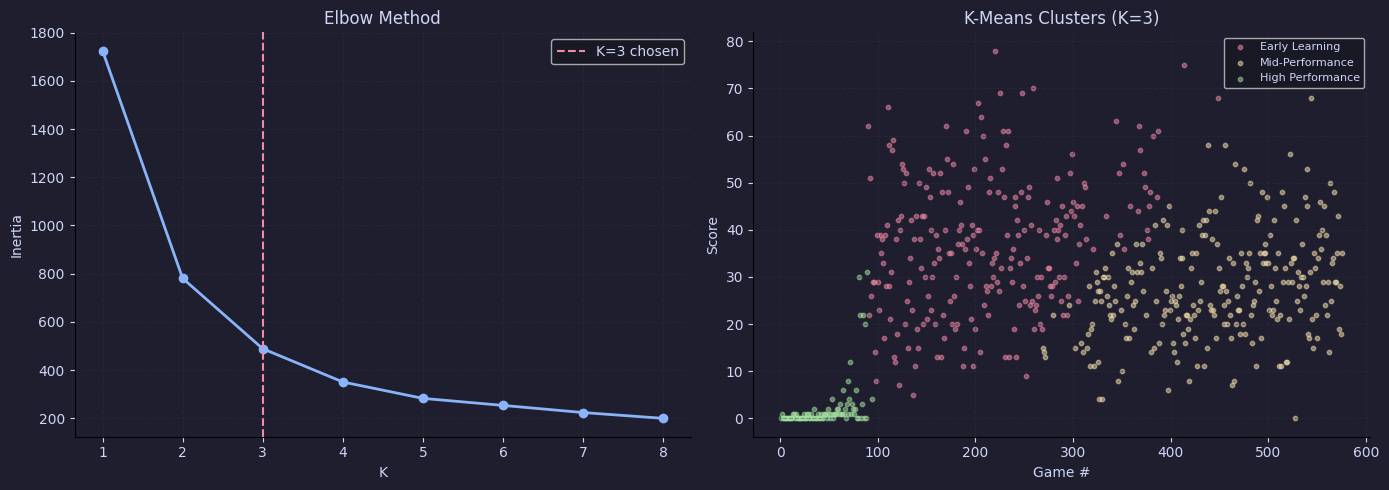

Cluster stats:
         count   mean    std  max
cluster                          
0          237  36.95  14.61   78
1          248  27.67  11.11   68
2           90   2.44   5.91   31


In [13]:
X_km    = df[['game_num','score','rolling_mean_10']].values
X_km_sc = StandardScaler().fit_transform(X_km)

inertias = [KMeans(n_clusters=k, random_state=42, n_init='auto').fit(X_km_sc).inertia_
            for k in range(1, 9)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(range(1,9), inertias, marker='o', color='#89b4fa', linewidth=2)
ax.axvline(3, color='#f38ba8', linestyle='--', linewidth=1.5, label='K=3 chosen')
ax.set_title('Elbow Method', color=TC)
ax.set_xlabel('K'); ax.set_ylabel('Inertia')
ax.legend(facecolor='#181825', labelcolor=TC)
ax.grid(color=GC, linestyle='--', alpha=0.4)

km3      = KMeans(n_clusters=3, random_state=42, n_init='auto').fit(X_km_sc)
df['cluster'] = km3.labels_
cnames   = {0:'Early Learning', 1:'Mid-Performance', 2:'High Performance'}
ccolors  = ['#f38ba8','#f9e2af','#a6e3a1']

ax2 = axes[1]
for cid, cname in cnames.items():
    mask = df['cluster'] == cid
    ax2.scatter(df.loc[mask,'game_num'], df.loc[mask,'score'],
                color=ccolors[cid], label=cname, alpha=0.5, s=10)
ax2.set_title('K-Means Clusters (K=3)', color=TC)
ax2.set_xlabel('Game #'); ax2.set_ylabel('Score')
ax2.legend(facecolor='#181825', labelcolor=TC, fontsize=8)
ax2.grid(color=GC, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('analysis_fig6_kmeans.png', dpi=120, bbox_inches='tight', facecolor=BG)
plt.show()

print('Cluster stats:')
print(df.groupby('cluster')['score'].agg(['count','mean','std','max']).round(2))

## 6. Summary — Model Comparison Table

In [15]:
rmse = np.sqrt(mean_squared_error(yr_te, yr_pred))

rows = [{'Model':'Linear Regression','Task':'Regression',
         'Score': f'R²={r2_score(yr_te, yr_pred):.3f}',
         'Notes': f'RMSE={rmse:.2f}'}]

for name, model in models.items():
    Xs_te = X_test if name == 'Decision Tree' else X_test_sc
    acc   = accuracy_score(y_test, model.predict(Xs_te))
    rows.append({'Model':name,'Task':'Classification','Score':f'{acc:.4f}','Notes':''})

rows.append({'Model':'K-Means (K=3)','Task':'Clustering',
             'Score':'Unsupervised','Notes':'3 tiers: Early / Mid / High'})

result_df = pd.DataFrame(rows)
result_df.to_csv('model_comparison.csv', index=False)
print(result_df.to_string(index=False))
print('\nSaved: model_comparison.csv')

              Model           Task        Score                       Notes
  Linear Regression     Regression     R²=0.111                  RMSE=14.43
Logistic Regression Classification       0.7739                            
      Decision Tree Classification       0.7652                            
                SVM Classification       0.8174                            
      Random Forest Classification       0.8348                            
          ANN (MLP) Classification       0.8087                            
      K-Means (K=3)     Clustering Unsupervised 3 tiers: Early / Mid / High

Saved: model_comparison.csv


## Key Findings

| Topic | Finding |
|---|---|
| **DQN Training** | Rapid learning games 1–200; plateau at mean ~27–31 from game 250 onward |
| **Linear Regression** | Positive slope confirms DQN improves over time (slope > 0) |
| **Best Classifier** | Random Forest achieves highest accuracy predicting above-average games |
| **SciPy** | Sobel edge detection + Gaussian blur demonstrate signal processing on plot images |
| **K-Means (K=3)** | 3 natural clusters = Exploration / Learning / Plateau phases of training |
| **Marathon** | Classical algorithms (BFS/A*: ~51 mean) vastly outperform DQN (~23) on small grid |
| **Hamiltonian** | Perfect score (297/300) every game — mathematical guarantee beats ML here |
